Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler


Loading the Dataset

In [3]:
# Load data
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

# Quick check
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (49993, 44)
Val shape: (10774, 44)
Test shape: (10868, 44)


Preprocessing

In [4]:
P_COLS = [f"p{i}" for i in range(1, 43)]

# Split features and labels
X_train = train_df[P_COLS].to_numpy(dtype=np.float32)
y_train = train_df["label_move_col"].to_numpy(dtype=np.int64)

X_val = val_df[P_COLS].to_numpy(dtype=np.float32)
y_val = val_df["label_move_col"].to_numpy(dtype=np.int64)

X_test = test_df[P_COLS].to_numpy(dtype=np.float32)  # no labels

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# One-hot encode labels
num_classes = 7
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
print("Data ready:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("Unique labels:", np.unique(y_train))



Data ready:
X_train: (49993, 42) y_train: (49993,)
X_val: (10774, 42) y_val: (10774,)
X_test: (10868, 42)
Unique labels: [0 1 2 3 4 5 6]


Build Dense Model

In [7]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(42,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()




C:\Users\tassn\Downloads\ancodatasim\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,615 (205.53 KB)

 Trainable params: 52,615 (205.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Training the Model

In [8]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=40,
    batch_size=64,
    verbose=1
)


Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3663 - loss: 1.7102 - val_accuracy: 0.4474 - val_loss: 1.5108
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4286 - loss: 1.5207 - val_accuracy: 0.4872 - val_loss: 1.4039
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4589 - loss: 1.4442 - val_accuracy: 0.5081 - val_loss: 1.3392
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4769 - loss: 1.3966 - val_accuracy: 0.5208 - val_loss: 1.3052
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4866 - loss: 1.3701 - val_accuracy: 0.5259 - val_loss: 1.2858
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4965 - loss: 1.3403 - val_accuracy: 0.5377 - val_loss: 1.2633
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5056 - loss: 1.3199 - val_accuracy: 0.5379 - val_loss: 1.2496
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5126 - loss: 1.3052 - val_accuracy: 0.

Evaluation

In [9]:
val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")


Validation Accuracy: 0.5790


 Predict on test set and save CSV

In [17]:
import numpy as np
import pandas as pd

# Predict on test data
y_test_pred = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1).astype(int)

# Create DataFrame with column name 'label_move_col'
NN_prediction = pd.DataFrame({
    "id": range(1, len(y_test_pred) + 1),
    "label_move_col": y_test_pred
})

# Save CSV
NN_prediction.to_csv("NN_prediction.csv", index=False)

print("CSV file 'NN_prediction.csv' created successfully!")


340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
CSV file 'NN_prediction.csv' created successfully!


Confusion Matrix

337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step


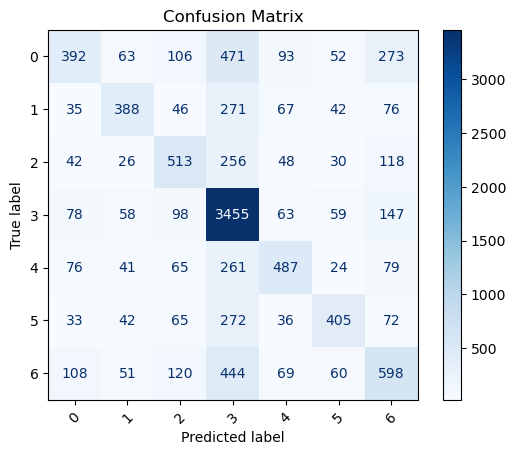

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict validation set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
